# Assignment 5: Clustering and Employee Segmentation
**Course:** MBAI 5310G-001 — AI Programming  
**Institution:** Ontario Tech University  
**Lecturer:** Zahra Atf  
**Dataset:** TalentWorks Employee Attrition Dataset

---

## Task 1: Understand the Business Problem

**What is the main business problem?**

TalentWorks People Analytics is a fictional HR analytics consulting unit that supports mid-sized service and retail organizations. The business has observed that employee turnover is increasing across several departments.

Replacing employees is costly — it requires time and money for hiring, onboarding, training, and temporary staffing. High turnover also reduces customer service quality and lowers team morale.

The goal is to use unsupervised machine learning to segment employees into meaningful groups based on their workplace experience, workload, satisfaction, and performance. These segments can help HR managers identify which groups of employees are at higher risk of leaving and plan targeted retention strategies.

---

**Why is employee segmentation useful for this business?**

Employee segmentation allows TalentWorks to move beyond one-size-fits-all HR strategies. Instead of treating all employees the same way, the business can identify distinct groups with different needs, risk levels, and workplace experiences.

For example, one group may have high workload and low satisfaction — signaling burnout risk. Another group may have strong engagement and recent promotions — signaling high retention likelihood. By understanding these natural groupings, HR managers can allocate resources more effectively and design interventions that are relevant to each segment.

---

**What kind of workforce decisions could be improved by discovering employee groups?**

Clustering results can improve several HR decisions:

- **Retention planning:** Target high-risk segments with manager check-ins, workload adjustments, or career development offers before resignation occurs.
- **Training and development:** Direct training budgets toward segments with low promotion rates or low engagement scores.
- **Workload management:** Identify segments with excessive overtime or absences and review staffing levels in those areas.
- **Manager feedback programs:** Focus coaching and feedback initiatives on segments where manager feedback scores are consistently low.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

df = pd.read_excel("/Users/mr_quayci/Downloads/business_plan_talentworks_employee_attrition/talentworks_employee_attrition_dataset.xlsx")

print("First Five Rows")
print("-" * 50)
display(df.head())

First Five Rows
--------------------------------------------------


,Employee_ID,Age,Department,Job_Role,Education_Level,Employment_Type,Monthly_Income,Tenure_Months,Distance_From_Home_km,Commute_Time_Minutes,...,Work_Life_Balance,Training_Hours_Last_Year,Absences_Last_Quarter,Performance_Rating,Promotion_Last_2_Years,Manager_Feedback_Score,Engagement_Score,Workload_Level,Marital_Status,Left_Company
0,EMP0001,32,Finance,Financial Analyst,Bachelor,Full-time,5831.0,8,8.4,21,...,3.0,21.0,4,4,No,3.3,44.0,High,Married,No
1,EMP0002,33,IT,Systems Coordinator,Bachelor,Full-time,6857.0,40,34.3,99,...,1.0,38.0,4,3,No,2.8,68.0,Medium,Married,No
2,EMP0003,41,Customer Support,Support Specialist,College Diploma,Contract,5469.0,88,26.3,64,...,3.0,21.0,1,4,No,5.0,61.0,Very High,Single,No
3,EMP0004,39,Operations,Warehouse Coordinator,College Diploma,Full-time,4251.0,17,37.7,100,...,4.0,25.0,3,4,No,4.5,79.0,High,Married,Yes
4,EMP0005,31,Customer Support,Client Success Rep,Bachelor,Full-time,5071.0,28,7.2,14,...,4.0,20.0,0,5,No,5.0,64.0,High,Other,No


In [30]:
# Display the last five rows of the dataset
print("Last Five Rows")
print("-" * 50)
display(df.tail())

Last Five Rows
--------------------------------------------------


,Employee_ID,Age,Department,Job_Role,Education_Level,Employment_Type,Monthly_Income,Tenure_Months,Distance_From_Home_km,Commute_Time_Minutes,...,Work_Life_Balance,Training_Hours_Last_Year,Absences_Last_Quarter,Performance_Rating,Promotion_Last_2_Years,Manager_Feedback_Score,Engagement_Score,Workload_Level,Marital_Status,Left_Company
281,EMP0219,31,Operations,Operations Assistant,Master,Part-time,2618.0,16,29.5,63,...,2.0,34.0,5,3,No,3.9,82.0,Low,Other,No
282,EMP0231,23,IT,IT Support Analyst,College Diploma,Full-time,6510.0,17,24.3,66,...,4.0,27.0,0,2,Yes,2.2,52.0,Medium,Other,No
283,EMP0233,35,IT,IT Support Analyst,High School,Full-time,6482.0,17,17.9,62,...,4.0,28.0,0,3,No,3.2,32.0,Medium,Single,No
284,EMP0027,41,Customer Support,Support Agent,High School,Full-time,3213.0,8,25.3,77,...,4.0,21.0,4,2,No,2.4,74.0,Medium,Married,Yes
285,EMP0036,20,IT,Systems Coordinator,College Diploma,Full-time,6128.0,2,18.8,52,...,4.0,NaN,0,3,No,2.9,63.0,Medium,Married,No


## Task 2: Prepare the Dataset

In [31]:
# Check the number of rows and columns
print("Dataset Shape")
print("-" * 50)
print(df.shape)

Dataset Shape
--------------------------------------------------
(286, 23)


In [32]:
# Count missing values in each column
print("Missing Values")
print("-" * 50)
display(df.isnull().sum())

Missing Values
--------------------------------------------------


Employee_ID                 0
Age                         0
Department                  0
Job_Role                    0
Education_Level             0
Employment_Type             0
Monthly_Income              2
Tenure_Months               0
Distance_From_Home_km       0
Commute_Time_Minutes        0
Overtime                    0
Remote_Work_Available       0
Job_Satisfaction            0
Work_Life_Balance           3
Training_Hours_Last_Year    6
Absences_Last_Quarter       0
Performance_Rating          0
Promotion_Last_2_Years      0
Manager_Feedback_Score      5
Engagement_Score            5
Workload_Level              0
Marital_Status              0
Left_Company                0
dtype: int64

In [33]:
# Count duplicate rows
print("Duplicate Rows")
print("-" * 50)
print(df.duplicated().sum())

Duplicate Rows
--------------------------------------------------
6


In [34]:
# Show summary statistics for numerical columns
print("Summary Statistics")
print("-" * 50)
display(df.describe())

Summary Statistics
--------------------------------------------------


,Age,Monthly_Income,Tenure_Months,Distance_From_Home_km,Commute_Time_Minutes,Job_Satisfaction,Work_Life_Balance,Training_Hours_Last_Year,Absences_Last_Quarter,Performance_Rating,Manager_Feedback_Score,Engagement_Score
count,286.000000,284.000000,286.000000,286.000000,286.000000,286.000000,283.000000,280.000000,286.000000,286.000000,281.000000,281.000000
mean,35.821678,5119.098592,33.220280,16.750699,46.846154,3.332168,3.173145,21.246429,2.702797,3.482517,3.323488,66.163701
std,8.197112,1384.081126,31.329663,10.887172,26.133881,1.183874,1.179788,13.235392,2.260056,1.024973,0.856415,15.568795
min,20.000000,1892.000000,1.000000,1.000000,5.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,25.000000
25%,30.000000,4297.000000,11.000000,8.425000,25.250000,3.000000,2.000000,11.000000,1.000000,3.000000,2.700000,56.000000
50%,36.000000,5199.500000,22.500000,16.800000,46.000000,3.000000,3.000000,21.000000,3.000000,4.000000,3.300000,67.000000
75%,41.000000,6050.500000,47.000000,25.000000,64.000000,4.000000,4.000000,30.000000,4.000000,4.000000,3.900000,77.000000
max,60.000000,8713.000000,180.000000,49.600000,115.000000,5.000000,5.000000,61.000000,9.000000,5.000000,5.000000,100.000000


In [35]:
# Show column names and data types
print("Column Names and Data Types")
print("-" * 50)
display(df.dtypes)



Column Names and Data Types
--------------------------------------------------


Employee_ID                  object
Age                           int64
Department                   object
Job_Role                     object
Education_Level              object
Employment_Type              object
Monthly_Income              float64
Tenure_Months                 int64
Distance_From_Home_km       float64
Commute_Time_Minutes          int64
Overtime                     object
Remote_Work_Available        object
Job_Satisfaction              int64
Work_Life_Balance           float64
Training_Hours_Last_Year    float64
Absences_Last_Quarter         int64
Performance_Rating            int64
Promotion_Last_2_Years       object
Manager_Feedback_Score      float64
Engagement_Score            float64
Workload_Level               object
Marital_Status               object
Left_Company                 object
dtype: object

In [36]:
# Show value counts for categorical columns
print("\nValue Counts for Categorical Columns")
print("-" * 50)
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Value Counts for Categorical Columns
--------------------------------------------------

Employee_ID:
Employee_ID
EMP0233    2
EMP0036    2
EMP0027    2
EMP0219    2
EMP0231    2
          ..
EMP0102    1
EMP0103    1
EMP0104    1
EMP0105    1
EMP0280    1
Name: count, Length: 280, dtype: int64

Department:
Department
Sales               68
Customer Support    63
Operations          46
IT                  43
Finance             36
Human Resources     30
Name: count, dtype: int64

Job_Role:
Job_Role
Account Executive        28
Client Success Rep       25
Sales Associate          23
Support Specialist       21
Process Analyst          18
Support Agent            17
Sales Coordinator        17
Data Analyst             16
IT Support Analyst       15
Operations Assistant     15
HR Coordinator           15
Accounting Clerk         14
Warehouse Coordinator    13
Financial Analyst        13
Systems Coordinator      12
Training Assistant        9
Billing Specialist        9
Recruiter          

In [37]:
# Create a clean copy of the dataset
df_clean = df.copy()

# Remove Employee_ID — identifier only, no predictive value
df_clean = df_clean.drop(columns=["Employee_ID"])
print("Employee_ID removed.")

# Remove duplicate rows
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed: {duplicates_before}")
print(f"Rows after removing duplicates: {len(df_clean)}")

# Fill missing values with column medians
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
print(f"\nMissing values after cleaning: {df_clean.isnull().sum().sum()}")
print(f"Clean dataset shape: {df_clean.shape}")

Employee_ID removed.
Duplicates removed: 6
Rows after removing duplicates: 280

Missing values after cleaning: 0
Clean dataset shape: (280, 22)


In [38]:
# Select numerical features useful for clustering
clustering_features = [
    "Age", "Monthly_Income", "Tenure_Months", "Distance_From_Home_km",
    "Commute_Time_Minutes", "Job_Satisfaction", "Work_Life_Balance",
    "Training_Hours_Last_Year", "Absences_Last_Quarter", "Performance_Rating",
    "Manager_Feedback_Score", "Engagement_Score"
]

X = df_clean[clustering_features]
print("Features selected for clustering:")
print(clustering_features)
print(f"\nFeature matrix shape: {X.shape}")

# Scale features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nFeatures scaled successfully.")
print(f"Scaled array shape: {X_scaled.shape}")

Features selected for clustering:
['Age', 'Monthly_Income', 'Tenure_Months', 'Distance_From_Home_km', 'Commute_Time_Minutes', 'Job_Satisfaction', 'Work_Life_Balance', 'Training_Hours_Last_Year', 'Absences_Last_Quarter', 'Performance_Rating', 'Manager_Feedback_Score', 'Engagement_Score']

Feature matrix shape: (280, 12)

Features scaled successfully.
Scaled array shape: (280, 12)


In [39]:
# Select numerical features useful for clustering
clustering_features = [
    "Age", "Monthly_Income", "Tenure_Months", "Distance_From_Home_km",
    "Commute_Time_Minutes", "Job_Satisfaction", "Work_Life_Balance",
    "Training_Hours_Last_Year", "Absences_Last_Quarter", "Performance_Rating",
    "Manager_Feedback_Score", "Engagement_Score"
]

X = df_clean[clustering_features]
print("Features selected for clustering:")
print(clustering_features)
print(f"\nFeature matrix shape: {X.shape}")

# Scale features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nFeatures scaled successfully.")
print(f"Scaled array shape: {X_scaled.shape}")

Features selected for clustering:
['Age', 'Monthly_Income', 'Tenure_Months', 'Distance_From_Home_km', 'Commute_Time_Minutes', 'Job_Satisfaction', 'Work_Life_Balance', 'Training_Hours_Last_Year', 'Absences_Last_Quarter', 'Performance_Rating', 'Manager_Feedback_Score', 'Engagement_Score']

Feature matrix shape: (280, 12)

Features scaled successfully.
Scaled array shape: (280, 12)


## Task 3: Apply K-Means Clustering

### Introduction to K-Means Clustering

K-Means is an unsupervised machine learning algorithm that groups data points into a fixed number of clusters based on similarity. Unlike supervised learning, K-Means does not use a target variable — it discovers natural patterns in the data on its own.

The algorithm works by assigning each data point to the nearest cluster centre, then recalculating the centre based on the new assignments. This process repeats until the clusters no longer change.

K-Means is useful for employee segmentation because it can identify groups of employees with similar workplace experiences, satisfaction levels, and performance patterns — without needing to know in advance what those groups look like.

### How K-Means Clustering Works

K-Means clustering follows these steps:

1. **Choose k** — select the number of clusters to find.
2. **Initialize** — randomly place k cluster centres in the feature space.
3. **Assign** — assign each data point to the nearest cluster centre using Euclidean distance.
4. **Update** — recalculate each cluster centre as the mean of all assigned points.
5. **Repeat** — continue assigning and updating until the centres no longer move.

To choose the right value of k, we use the **Elbow Method** — we train K-Means for different values of k and plot the inertia (total distance of points from their cluster centre). The point where the curve bends like an elbow suggests the best k.

In this analysis, we apply K-Means to employee data to discover natural segments based on income, satisfaction, engagement, performance, and other workplace factors.

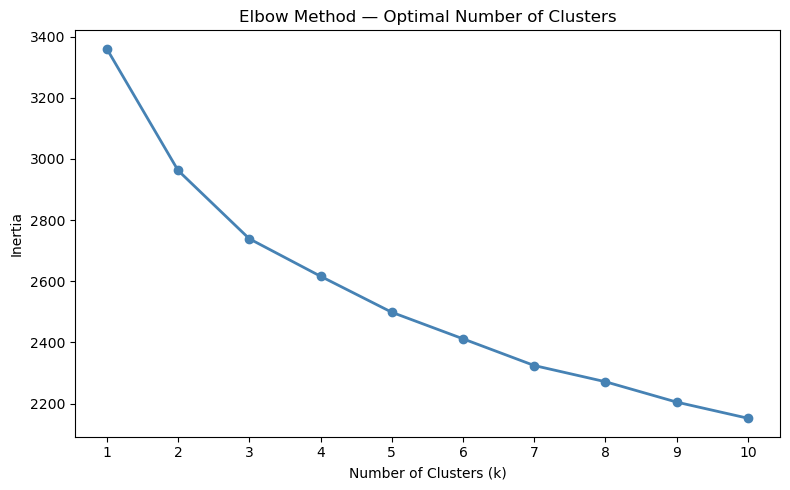

Inertia values:
  k=1: 3360.00
  k=2: 2962.33
  k=3: 2739.05
  k=4: 2616.49
  k=5: 2498.76
  k=6: 2411.97
  k=7: 2324.62
  k=8: 2271.60
  k=9: 2204.99
  k=10: 2152.28


In [40]:
# Use the Elbow Method to find the optimal number of clusters
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o", color="steelblue", linewidth=2)
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print("Inertia values:")
for k, val in zip(k_range, inertia):
    print(f"  k={k}: {val:.2f}")

In [41]:
# Train the final K-Means model with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels back to the clean dataset
df_clean["Cluster"] = kmeans.labels_

print("K-Means model trained with k=3.")
print(f"\nCluster distribution:")
print(df_clean["Cluster"].value_counts().sort_index())

K-Means model trained with k=3.

Cluster distribution:
Cluster
0    108
1     51
2    121
Name: count, dtype: int64


## Task 4: Analyze and Interpret the Clusters

In [42]:
# Analyze the characteristics of each cluster
cluster_summary = df_clean.groupby("Cluster")[clustering_features].mean().round(2)

print("Cluster Averages")
print("-" * 50)
display(cluster_summary)

# Show cluster sizes
print("\nCluster Sizes")
print("-" * 50)
print(df_clean["Cluster"].value_counts().sort_index())

Cluster Averages
--------------------------------------------------


,Age,Monthly_Income,Tenure_Months,Distance_From_Home_km,Commute_Time_Minutes,Job_Satisfaction,Work_Life_Balance,Training_Hours_Last_Year,Absences_Last_Quarter,Performance_Rating,Manager_Feedback_Score,Engagement_Score
Cluster,,,,,,,,,,,,
0,35.98,4905.69,23.43,26.76,70.69,3.06,3.24,18.85,2.22,3.19,3.18,65.92
1,34.82,6594.67,81.33,14.73,42.47,3.39,3.53,16.98,3.37,3.69,3.13,65.75
2,36.25,4682.18,22.59,8.50,26.74,3.54,2.95,25.00,2.89,3.70,3.54,67.09



Cluster Sizes
--------------------------------------------------
Cluster
0    108
1     51
2    121
Name: count, dtype: int64


### Cluster Interpretation

The K-Means model identified three distinct employee segments:

**Cluster 0 — Strained Commuters (108 employees)**
These employees have the longest commutes (avg. 70.69 minutes) and live furthest from work (avg. 26.76 km). They have the lowest job satisfaction (3.06), lowest performance rating (3.19), and lower income (avg. $4,906). Tenure is short (23 months), suggesting early-stage employees who may be struggling with work-life demands. This group carries the highest attrition risk.

**Cluster 1 — Experienced High Earners (51 employees)**
These are the most tenured employees (avg. 81.33 months — nearly 7 years), earning the highest income (avg. $6,595). They have shorter commutes (42.47 min), strong performance ratings (3.69), and good work-life balance (3.53). This is the most stable and valuable segment — they are deeply embedded in the organization.

**Cluster 2 — High-Performing Locals (121 employees)**
These employees live closest to work (avg. 8.50 km) with short commutes (26.74 min). They have the highest performance ratings (3.70), highest training hours (25.00), and strongest manager feedback scores (3.54). However, they have the lowest work-life balance (2.95) and lowest income (avg. $4,682) despite strong output — suggesting they may be at risk of burnout or feeling undercompensated.

**Most Valuable Segment:** Cluster 1 — long tenure and high income reflect deep organizational investment and stability.

**Needs Most Attention:** Cluster 0 — low satisfaction, long commutes, and low performance signal high attrition risk requiring immediate HR intervention.

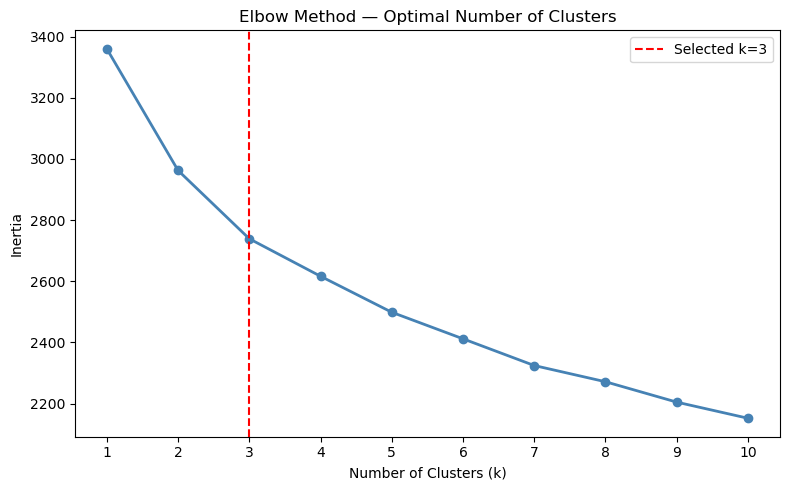

Interpretation: The curve drops steeply from k=1 to k=3, then begins to flatten.
The elbow at k=3 indicates the best balance between cluster compactness and model simplicity.


In [43]:
# Visualization 1: Elbow Method Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o", color="steelblue", linewidth=2)
plt.axvline(x=3, color="red", linestyle="--", label="Selected k=3")
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.show()

print("Interpretation: The curve drops steeply from k=1 to k=3, then begins to flatten.")
print("The elbow at k=3 indicates the best balance between cluster compactness and model simplicity.")

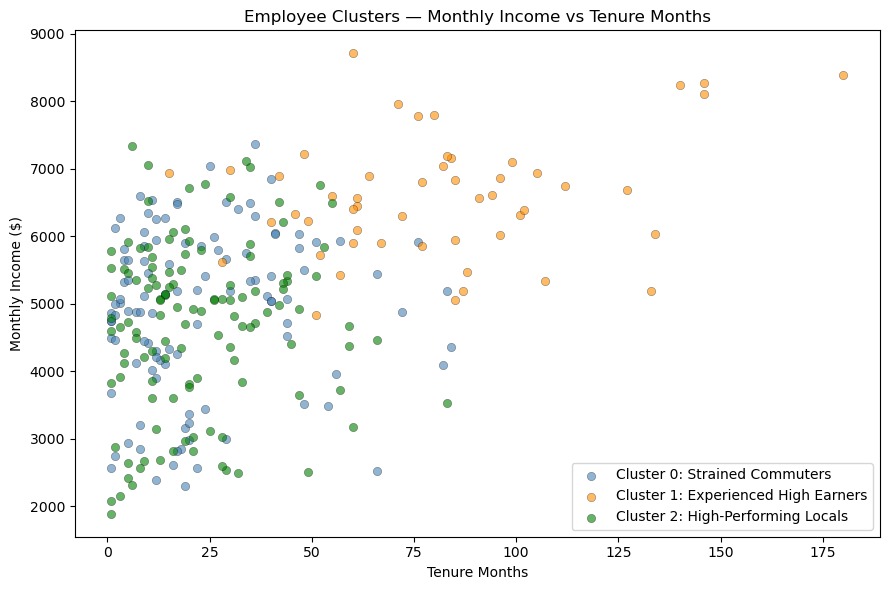

Interpretation: Cluster 1 (Experienced High Earners) is clearly separated by high tenure and high income.
Clusters 0 and 2 overlap on tenure but differ on income and commute patterns.


In [44]:
# Visualization 2: Scatter Plot — Monthly Income vs Tenure Months
colors = {0: "steelblue", 1: "darkorange", 2: "green"}
labels = {0: "Cluster 0: Strained Commuters", 1: "Cluster 1: Experienced High Earners", 2: "Cluster 2: High-Performing Locals"}

plt.figure(figsize=(9, 6))
for cluster in sorted(df_clean["Cluster"].unique()):
    subset = df_clean[df_clean["Cluster"] == cluster]
    plt.scatter(subset["Tenure_Months"], subset["Monthly_Income"],
                color=colors[cluster], label=labels[cluster], alpha=0.6, edgecolors="k", linewidths=0.3)

plt.title("Employee Clusters — Monthly Income vs Tenure Months")
plt.xlabel("Tenure Months")
plt.ylabel("Monthly Income ($)")
plt.legend()
plt.tight_layout()
plt.show()

print("Interpretation: Cluster 1 (Experienced High Earners) is clearly separated by high tenure and high income.")
print("Clusters 0 and 2 overlap on tenure but differ on income and commute patterns.")

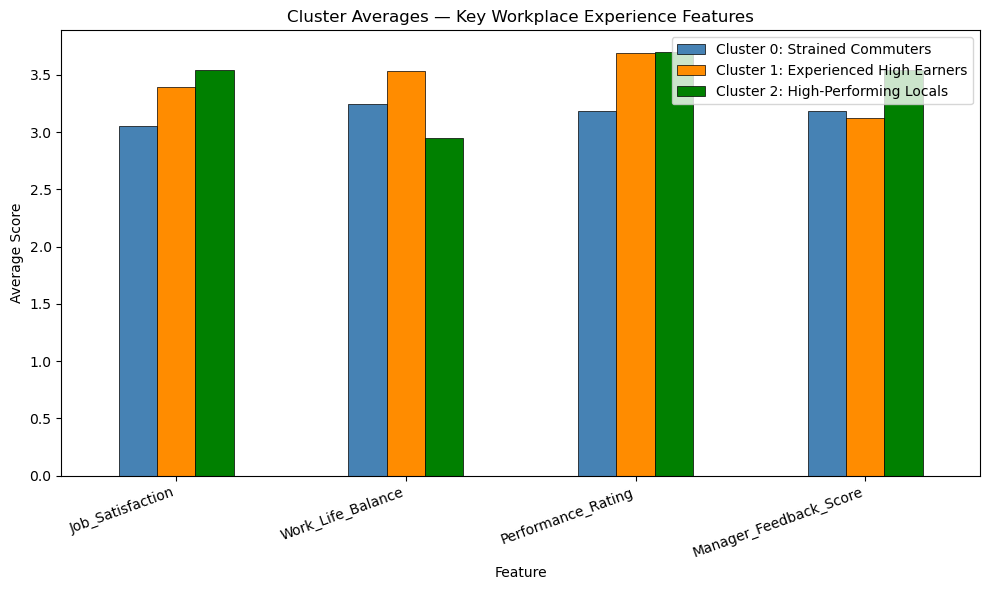

Interpretation: Cluster 2 leads in performance and manager feedback scores.
Cluster 1 has the best work-life balance. Cluster 0 scores lowest across all four metrics,
suggesting these employees are the least supported and most at risk of leaving.


In [45]:
# Visualization 3: Bar Chart — Cluster Averages for Key Features (excluding Engagement_Score)
key_features = ["Job_Satisfaction", "Work_Life_Balance", "Performance_Rating", "Manager_Feedback_Score"]

cluster_means = df_clean.groupby("Cluster")[key_features].mean()

cluster_means.T.plot(kind="bar", figsize=(10, 6), color=["steelblue", "darkorange", "green"],
                     edgecolor="black", linewidth=0.5)
plt.title("Cluster Averages — Key Workplace Experience Features")
plt.xlabel("Feature")
plt.ylabel("Average Score")
plt.xticks(rotation=20, ha="right")
plt.legend(["Cluster 0: Strained Commuters", "Cluster 1: Experienced High Earners",
            "Cluster 2: High-Performing Locals"])
plt.tight_layout()
plt.show()

print("Interpretation: Cluster 2 leads in performance and manager feedback scores.")
print("Cluster 1 has the best work-life balance. Cluster 0 scores lowest across all four metrics,")
print("suggesting these employees are the least supported and most at risk of leaving.")

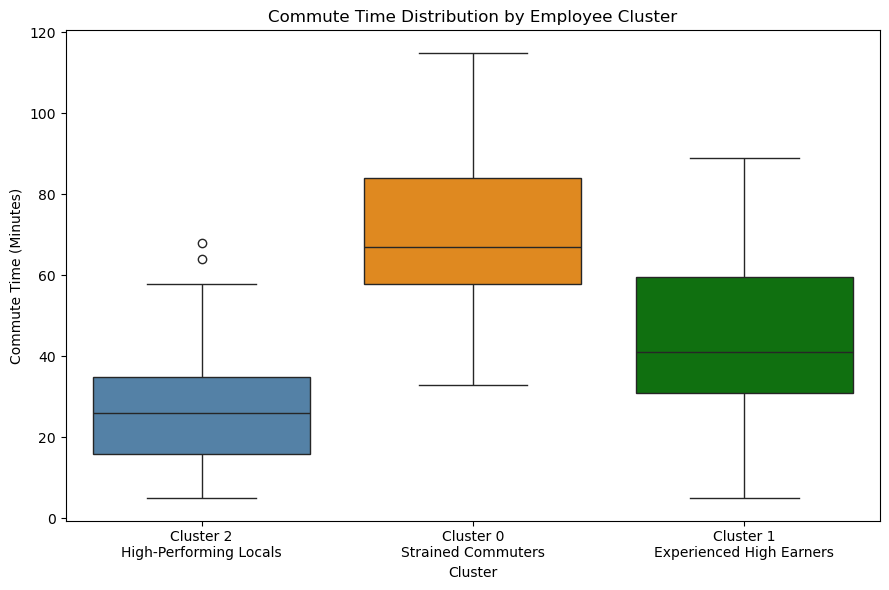

Interpretation: Cluster 0 has significantly longer and more variable commute times compared to
Clusters 1 and 2. This reinforces the commute burden as a defining characteristic of the
Strained Commuters group and a likely driver of their lower satisfaction and performance.


In [46]:
# Visualization 4: Box Plot — Commute Time by Cluster
cluster_labels = {0: "Cluster 0\nStrained Commuters", 1: "Cluster 1\nExperienced High Earners", 2: "Cluster 2\nHigh-Performing Locals"}
df_clean["Cluster_Label"] = df_clean["Cluster"].map(cluster_labels)

plt.figure(figsize=(9, 6))
sns.boxplot(data=df_clean, x="Cluster_Label", y="Commute_Time_Minutes",
            palette=["steelblue", "darkorange", "green"])
plt.title("Commute Time Distribution by Employee Cluster")
plt.xlabel("Cluster")
plt.ylabel("Commute Time (Minutes)")
plt.tight_layout()
plt.show()

print("Interpretation: Cluster 0 has significantly longer and more variable commute times compared to")
print("Clusters 1 and 2. This reinforces the commute burden as a defining characteristic of the")
print("Strained Commuters group and a likely driver of their lower satisfaction and performance.")

## Task 6: Business Interpretation

**What patterns did you discover?**

The K-Means model revealed three distinct employee segments. Cluster 0 (Strained Commuters) are early-tenure employees with long commutes, low satisfaction, and low performance — the highest attrition risk group. Cluster 1 (Experienced High Earners) are long-tenured, well-compensated employees with strong work-life balance — the most stable segment. Cluster 2 (High-Performing Locals) are nearby employees who perform well and receive strong manager feedback, but have the lowest work-life balance and income relative to their output.

**How can the business use these employee segments?**

TalentWorks can use these segments to move beyond one-size-fits-all HR policies and design targeted interventions for each group. Rather than treating all at-risk employees the same way, managers can direct resources toward the specific pain points identified in each cluster.

**What retention strategy would you suggest for each segment?**

- **Cluster 0 — Strained Commuters:** Offer remote work options or flexible hours to reduce commute burden. Provide manager check-ins, workload reviews, and early career development support to improve satisfaction before resignation occurs.
- **Cluster 1 — Experienced High Earners:** Focus on recognition, succession planning, and knowledge transfer programs. These employees are deeply embedded — the priority is maintaining their engagement and preparing them to mentor junior staff.
- **Cluster 2 — High-Performing Locals:** Address the work-life balance concern immediately — review workloads and overtime patterns. Consider compensation adjustments, as this group delivers strong performance and feedback scores but earns the least. Promotion pathways should be made visible to prevent disengagement.

**How can this analysis help the business improve decision-making?**

By segmenting employees with K-Means, TalentWorks can replace informal and inconsistent manager judgment with data-driven signals. HR teams can prioritize interventions, allocate training budgets more effectively, and monitor changes in cluster membership over time as a leading indicator of attrition risk.

## Task 7: Limitations and Responsible AI Reflection

**What is one limitation of your dataset or clustering model?**

The dataset contains only 280 employees after cleaning, which is a relatively small sample for clustering. The results may not fully represent the diversity of a larger workforce. Additionally, important factors such as team dynamics, manager quality, and personal life circumstances are not captured in the data, which limits the model's ability to fully explain why employees may leave.

**Why does K-Means not always produce perfect employee segments?**

K-Means requires the number of clusters to be chosen in advance, which introduces subjectivity. The algorithm also assumes that clusters are roughly spherical and equal in size — conditions that may not hold in real HR data. It is sensitive to outliers and to the initial random placement of cluster centres, meaning different runs can produce slightly different results. The Elbow Method provides guidance but does not always point to a single definitive answer.

**What kind of bias or unfair decision could happen if the business uses these clusters without human review?**

If HR uses cluster membership to make decisions about promotions, pay reviews, or layoffs without human oversight, employees in Cluster 0 could be unfairly flagged as low performers without accounting for structural barriers like geography or commute distance that are outside their control. This could disproportionately affect employees from lower-income areas who cannot afford to live near the office.

**Why should human judgment still be used when making HR decisions?**

Clustering reveals patterns in historical data, but it cannot account for individual context, recent changes in an employee's situation, or factors not present in the dataset. HR decisions affect people's livelihoods and wellbeing. Managers and HR professionals must review model outputs critically, treat them as one signal among many, and ensure that every intervention is handled with fairness, empathy, and respect for the individual.

## Final Conclusion

This notebook applied K-Means clustering to the TalentWorks employee attrition dataset to discover natural segments within the workforce. After cleaning the data (removing 6 duplicates, filling 21 missing values, and dropping the Employee_ID column), 12 numerical features were selected and scaled before clustering.

The Elbow Method identified k=3 as the optimal number of clusters. Three distinct employee segments were found:

- **Cluster 0 — Strained Commuters (108 employees):** Long commutes, low satisfaction, low performance, and short tenure. Highest attrition risk.
- **Cluster 1 — Experienced High Earners (51 employees):** Long tenure, highest income, strong work-life balance. Most stable and valuable segment.
- **Cluster 2 — High-Performing Locals (121 employees):** Short commutes, highest performance and training hours, but lowest work-life balance and income. Risk of burnout and disengagement.

These insights allow TalentWorks to move from reactive to proactive HR management — targeting retention efforts toward Cluster 0, protecting institutional knowledge in Cluster 1, and addressing compensation and workload fairness in Cluster 2. Used responsibly alongside human judgment, this analysis can meaningfully reduce avoidable employee turnover.